# Import Library & Dataset

In [1]:
# Import libraries
import pandas as pd
import mlflow
from mlflow import sklearn
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
from sklearn.feature_extraction.text import TfidfVectorizer
from imblearn.over_sampling import RandomOverSampler

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, accuracy_score
from sklearn.model_selection import GridSearchCV

import joblib
mlflow.set_experiment("ai-text-clf")

<Experiment: artifact_location='file:///C:/Users/RRMSU/Documents/GitHub/AI_or_Human/mlruns/147803855296939575', creation_time=1745803478149, experiment_id='147803855296939575', last_update_time=1745803478149, lifecycle_stage='active', name='ai-text-clf', tags={}>

In [2]:
# Set seed
seed = 1

In [3]:
# Load dataset
def load_parquet_files(file_paths):
    dataframes = [pd.read_parquet(file, engine = "pyarrow") for file in file_paths]
    return pd.concat(dataframes, ignore_index = True)

parquet_files = ["data/train-00000-of-00007-bc5952582e004d67.parquet", 
                 "data/train-00001-of-00007-71c80017bc45f30d.parquet", 
                 "data/train-00002-of-00007-ee2d43f396e78fbc.parquet", 
                 "data/train-00003-of-00007-529931154b42b51d.parquet", 
                 "data/train-00004-of-00007-b269dc49374a2c0b.parquet", 
                 "data/train-00005-of-00007-3dce5e05ddbad789.parquet",
                 "data/train-00006-of-00007-3d8a471ba0cf1c8d.parquet"
                ]

df_full = load_parquet_files(parquet_files)
df_full.head()

,source,id,text
0,human,0,12 Years a Slave: An Analysis of the Film Essa...
1,human,1,20+ Social Media Post Ideas to Radically Simpl...
2,human,2,2022 Russian Invasion of Ukraine in Global Med...
3,human,3,533 U.S. 27 (2001) Kyllo v. United States: The...
4,human,4,A Charles Schwab Corporation Case Essay\n\nCha...


In [4]:
# Full dataset's shape
df_full.shape

(1392522, 3)

In [5]:
# Define the sample size 
sample_fraction = 0.01
df, _ = train_test_split(df_full, train_size = sample_fraction, stratify = df_full['source'], random_state = seed)
df = df.reset_index(drop = True)
df.shape

(13925, 3)

# IDE

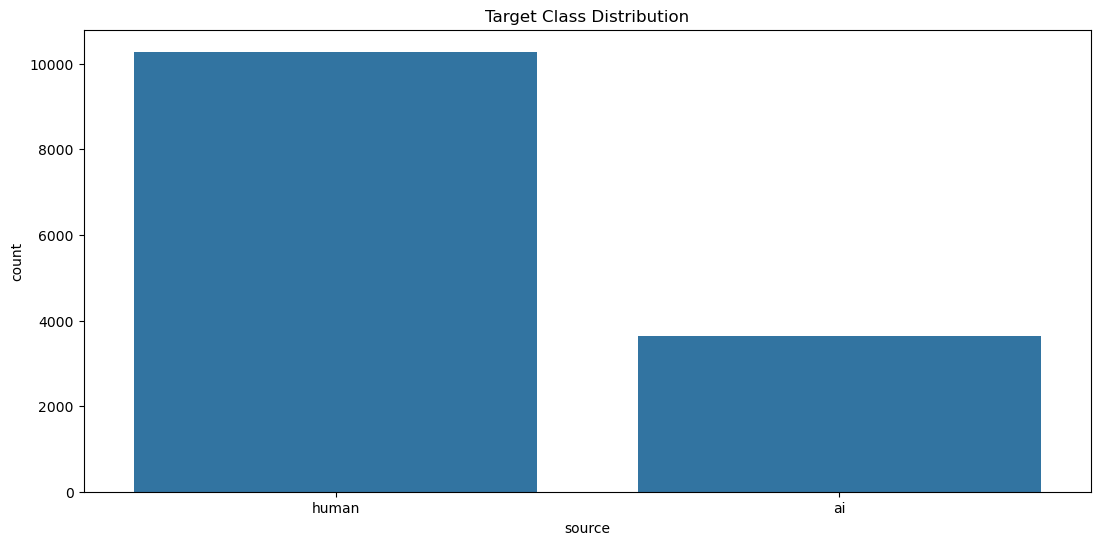

In [6]:
# Class distribution
f, ax = plt.subplots(figsize = (13, 6))
sns.countplot(x = 'source', data = df)
plt.title("Target Class Distribution")
plt.show()

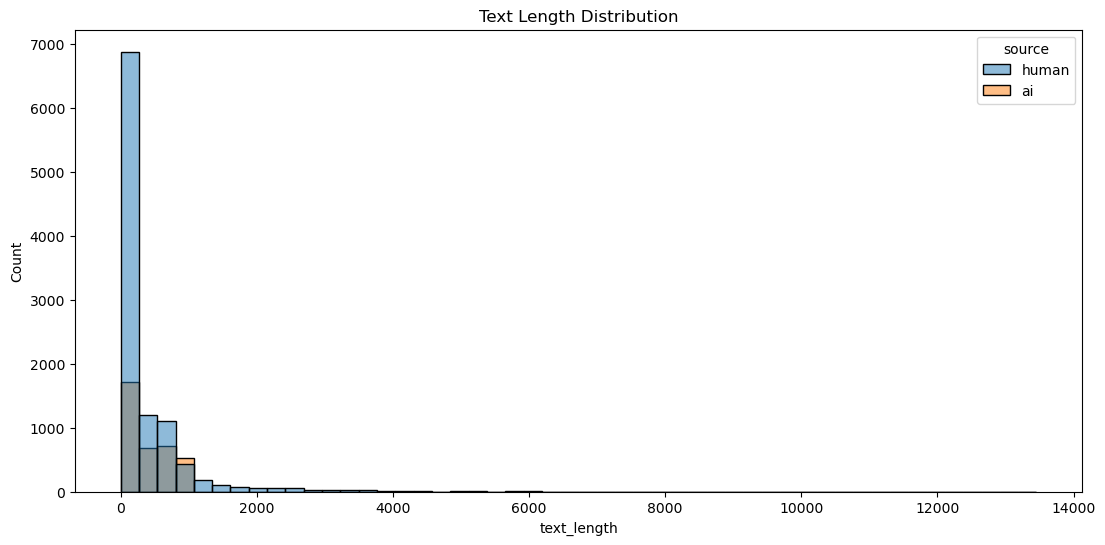

In [7]:
# Text length analysis
f, ax = plt.subplots(figsize = (13, 6))
df['text_length'] = df['text'].apply(lambda x: len(x.split()))
sns.histplot(df, x = 'text_length', hue = 'source', bins = 50)
plt.title("Text Length Distribution")
plt.show()

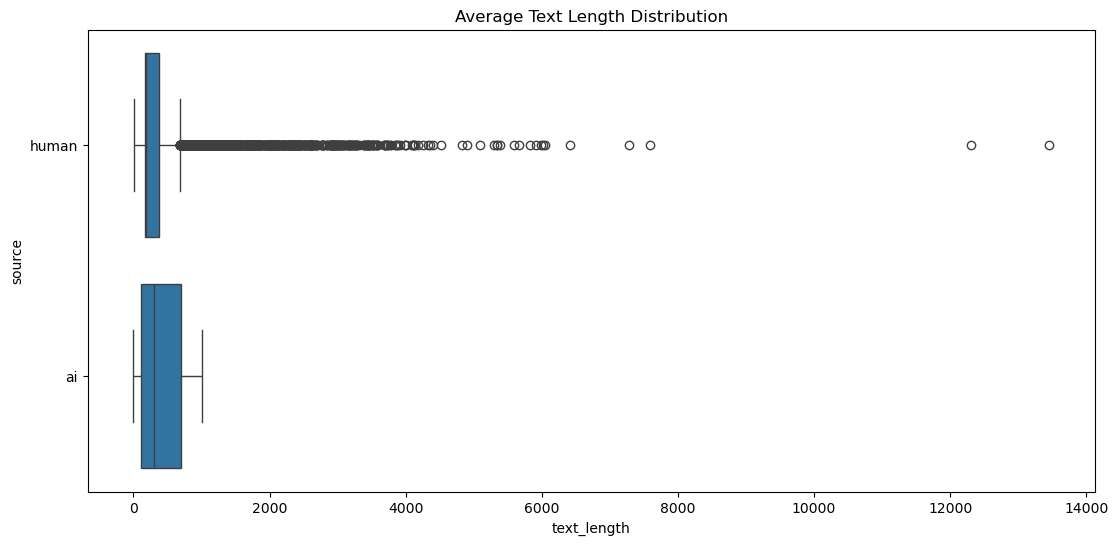

In [8]:
# Average text length analysis
f, ax = plt.subplots(figsize = (13, 6))
sns.boxplot(df, x = 'text_length', y = 'source')
plt.title("Average Text Length Distribution")
plt.show()

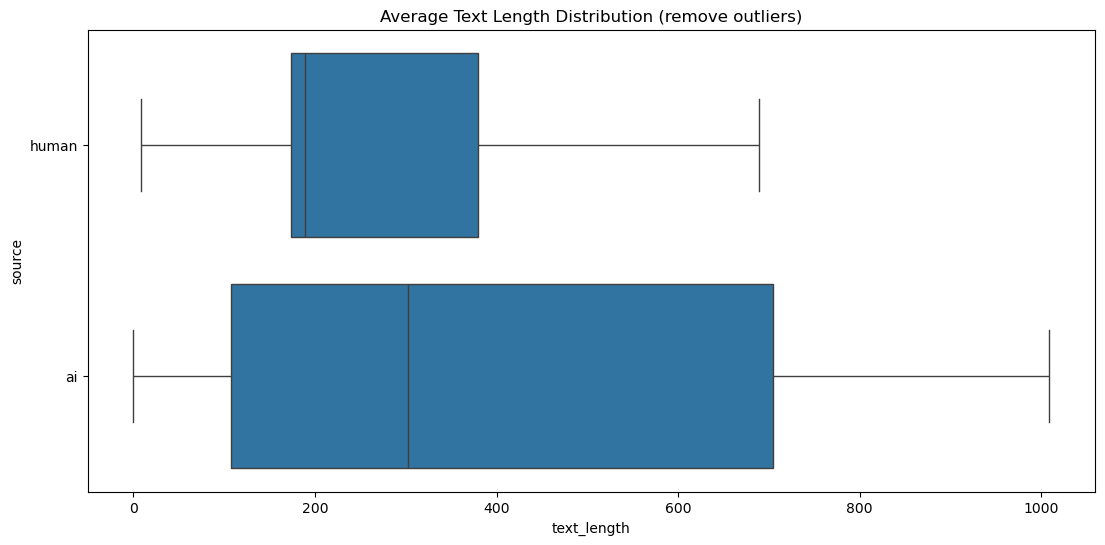

In [9]:
# Average text length analysis without outliers
f, ax = plt.subplots(figsize = (13, 6))
sns.boxplot(df, x = 'text_length', y = 'source', showfliers = False)
plt.title("Average Text Length Distribution (remove outliers)")
plt.show()

In [10]:
# Text length distribution
df.groupby("source")[['source', 'text_length']].describe()

text_length                                                            
             count        mean         std  min     25%    50%    75%      max
source                                                                        
ai          3644.0  387.933315  299.162296  0.0  107.75  302.0  705.0   1009.0
human      10281.0  403.937749  577.402107  8.0  174.00  189.0  380.0  13456.0

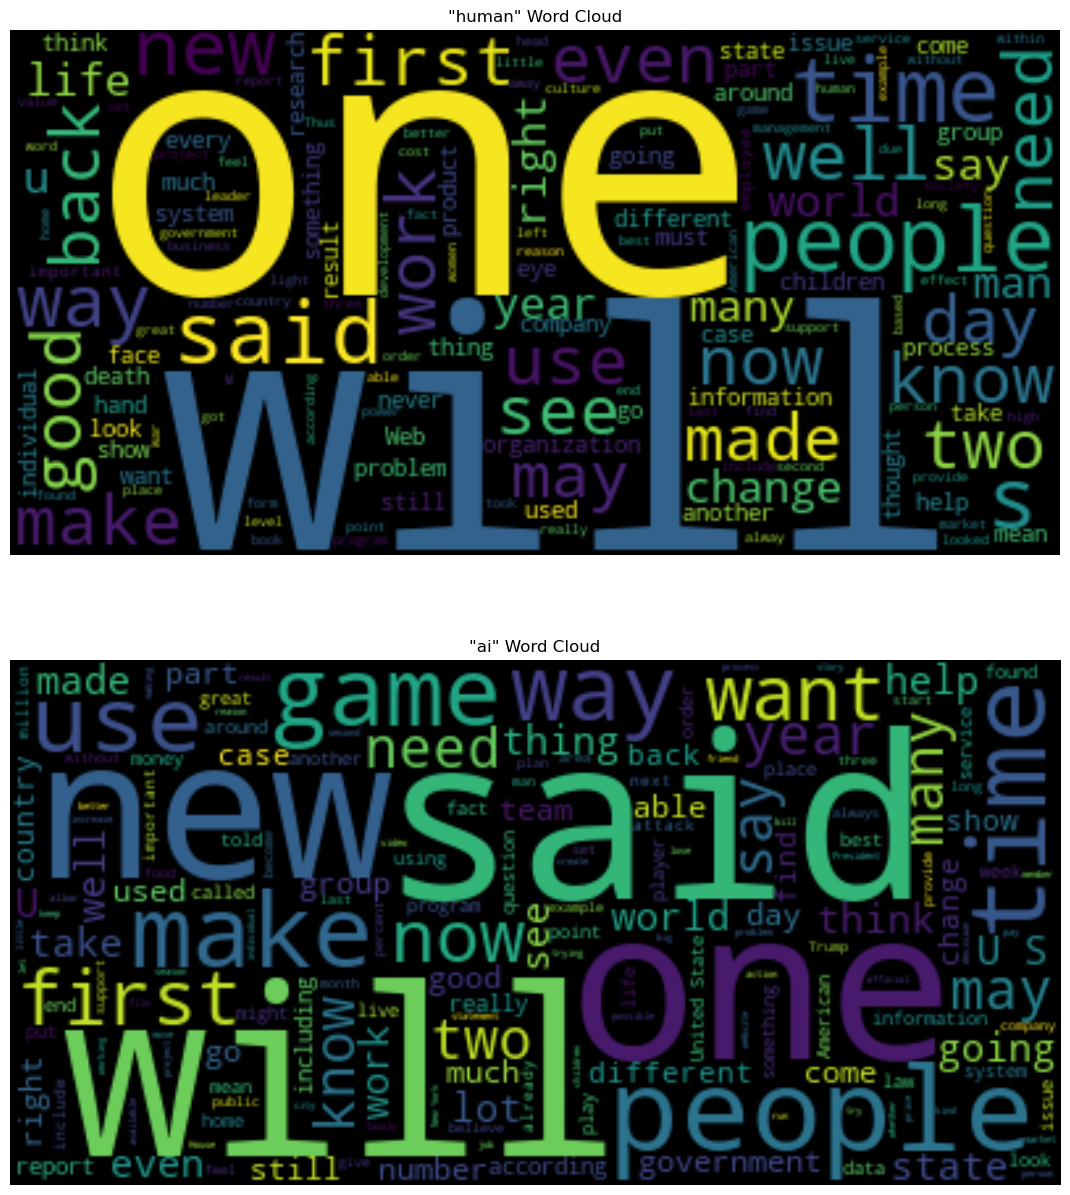

In [11]:
# Word cloud (only contains the first 1000 rows of each label)
fig, axs = plt.subplots(2,1, figsize = (100, 15))
for i in range(len(df['source'].unique())):
    txt = ' '.join(df[df['source'] == df['source'].unique()[i]]['text'].head(1000).astype(str))
    wordcloud = WordCloud().generate(txt)
    title = '"' + df['source'].unique()[i] + '"' + ' Word Cloud'
    
    axs[i].imshow(wordcloud, interpolation = 'bilinear')
    axs[i].axis("off")
    axs[i].set_title(title)

# Text Preprocessing

In [12]:
# Text Sample
print(df['text'][0])

``Mr..... Sameson?'' 
 
 ``That's me.'' 
 
 ``Well, hello Mr. Sameson,'' said the chubby guy with the blond slick sideways hair, ``Foggy Nelson, Nelson and Murdock. This is my partner, Matthew Murdock.'' 
 
 Matthew came walking in slightly clumsy, holding a suitcase in his left hand and a blind man's cane in his right. He wore glasses that obscured his eyes. Blind. What a shame, everyone can appreciate his looks but himself. I took his hand and shook it. Quite a grip for a blind man. Does he work out? 
 
 ``We are here to help you and represent you in your current dilemma concerning the Tilton boys. ``, Foggy said as he sat his plump down and pulled a file out. Matthew took out a laptop. 
 
 ``Can you recount what happened yesterdaynight around 3:00 AM, sir? ``, Matthew asked me in one of those cold lawyer voices. Kinda weird how he doen't look at you. As if you're in between walls with the guy, but he knows you're there. 
 
 ``They tried to rob me. I took a gun out of the


In [13]:
# Basic text preprocessing
def preprocess_text(text):
    text = text.lower()
    text = re.sub(r'\n', '', text)  # Remove newline characters
    text = re.sub(r'[^a-zA-Z0-9\s]', '', text)  # Remove special characters
    text = re.sub(r'\s+', ' ', text).strip()  # Remove extra spaces
    return text

df['clean_text'] = df['text'].apply(preprocess_text)
df = df[df['clean_text'].str.len() > 5]
df = df.reset_index(drop = True)

In [14]:
df = df.dropna(subset=['clean_text'])  # Remove rows where 'clean_text' is NaN
df = df[df['clean_text'].str.strip() != '']  # Remove empty strings

In [15]:
# TF-IDF feature extraction
vectorizer = TfidfVectorizer(max_features = 200, stop_words = 'english', ngram_range = (1, 2))
X = vectorizer.fit_transform(df['clean_text'])
y = df['source'].map({'human': 0, 'ai': 1})

In [16]:
print("Original target class's distribution:")
print(y.value_counts())

ros = RandomOverSampler(sampling_strategy = 'minority', random_state = seed)
X_resampled, y_resampled = ros.fit_resample(X, y)

print("Oversampled target class's distribution:")
print(y_resampled.value_counts())

Original target class's distribution:
source
0    10281
1     3635
Name: count, dtype: int64
Oversampled target class's distribution:
source
0    10281
1    10281
Name: count, dtype: int64


In [17]:
X_train_bal, X_test_bal, y_train_bal, y_test_bal = train_test_split(X_resampled, y_resampled, test_size = 0.2, random_state = seed)

# Model Training

In [18]:
classifiers = {
    "Logistic Regression": LogisticRegression(max_iter = 200, random_state = seed),
    "Random Forest": RandomForestClassifier(n_estimators = 100, random_state = seed),
    "Gradient Boosting": GradientBoostingClassifier(random_state = seed),
    "SVM": SVC(random_state = seed),
    "KNN": KNeighborsClassifier()
}

In [19]:
for name, clf in classifiers.items():
    # Train (fit) the model
    clf.fit(X_train_bal, y_train_bal)
    
    # Predict on the test set
    y_pred = clf.predict(X_test_bal)
    
    # Calculate performance metrics
    print(f"===== {name} =====")
    print("Accuracy:", accuracy_score(y_test_bal, y_pred))
    print("Classification Report:")
    print(classification_report(y_test_bal, y_pred, target_names=["Human", "AI"]))
    print("\n")

===== Logistic Regression =====
Accuracy: 0.7692681740821785
Classification Report:
              precision    recall  f1-score   support

       Human       0.80      0.72      0.76      2078
          AI       0.74      0.81      0.78      2035

    accuracy                           0.77      4113
   macro avg       0.77      0.77      0.77      4113
weighted avg       0.77      0.77      0.77      4113



===== Random Forest =====
Accuracy: 0.9149039630440068
Classification Report:
              precision    recall  f1-score   support

       Human       0.95      0.87      0.91      2078
          AI       0.88      0.96      0.92      2035

    accuracy                           0.91      4113
   macro avg       0.92      0.92      0.91      4113
weighted avg       0.92      0.91      0.91      4113



===== Gradient Boosting =====
Accuracy: 0.8076829564794554
Classification Report:
              precision    recall  f1-score   support

       Human       0.87      0.73      0.79

## Deep Learning Model

In [20]:
import re
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from collections import defaultdict

from sklearn.preprocessing import LabelEncoder
from nltk.tokenize import word_tokenize
import nltk
nltk.download('punkt')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\RRMSU\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [24]:
# Create simple_tokenizer function
def simple_tokenizer(text):
    return re.findall(r'\b\w+\b', text.lower())

In [25]:
# Label encoding
df['label'] = LabelEncoder().fit_transform(df['source'])

# Tokenization
df['tokens'] = df['tokens'] = df['clean_text'].apply(simple_tokenizer)

In [26]:
def load_glove(file_path, embedding_dim = 100):
    embeddings = {}
    with open(file_path, 'r', encoding = 'utf-8') as f:
        for line in f:
            parts = line.split()
            word = parts[0]
            vector = np.array(parts[1:], dtype = 'float32')
            embeddings[word] = vector
    return embeddings

glove_path = 'glove.6B.100d.txt'
embedding_dim = 100
glove_embeddings = load_glove(glove_path, embedding_dim)

In [27]:
# Build vocabulary
word2idx = {"<PAD>": 0, "<UNK>": 1}
idx = 2
for tokens in df['tokens']:
    for token in tokens:
        if token.lower() not in word2idx:
            word2idx[token.lower()] = idx
            idx += 1

# Convert to sequences
max_len = 200
def encode_and_pad(tokens):
    ids = [word2idx.get(token.lower(), word2idx["<UNK>"]) for token in tokens]
    return ids[:max_len] + [0] * max(0, max_len - len(ids))

df['input_ids'] = df['tokens'].apply(encode_and_pad)

# Create embedding matrix
vocab_size = len(word2idx)
embedding_matrix = np.zeros((vocab_size, embedding_dim))

for word, i in word2idx.items():
    if word in glove_embeddings:
        embedding_matrix[i] = glove_embeddings[word]

In [28]:
class TextDataset(Dataset):
    def __init__(self, inputs, labels):
        self.inputs = torch.tensor(inputs, dtype = torch.long)
        self.labels = torch.tensor(labels, dtype = torch.float32)

    def __len__(self):
        return len(self.inputs)

    def __getitem__(self, idx):
        return self.inputs[idx], self.labels[idx]

X_train_dl, X_test_dl, y_train_dl, y_test_dl = train_test_split(df['input_ids'].tolist(), df['label'].tolist(), test_size = 0.2, random_state = seed)

train_dataset = TextDataset(X_train_dl, y_train_dl)
test_dataset = TextDataset(X_test_dl, y_test_dl)

train_loader = DataLoader(train_dataset, batch_size = 32, shuffle = True)
test_loader = DataLoader(test_dataset, batch_size = 32)

In [29]:
class FFNN(nn.Module):
    def __init__(self, vocab_size, embedding_dim, embedding_matrix):
        super(FFNN, self).__init__()
        self.embedding = nn.Embedding.from_pretrained(torch.tensor(embedding_matrix, dtype = torch.float32), freeze = True)
        self.pool = nn.AdaptiveAvgPool1d(1)
        self.fc = nn.Sequential(
            nn.Linear(embedding_dim, 64),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(64, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        x = self.embedding(x).permute(0, 2, 1)
        x = self.pool(x).squeeze(2)
        return self.fc(x)

In [30]:
class TextCNN(nn.Module):
    def __init__(self, vocab_size, embedding_dim, embedding_matrix):
        super(TextCNN, self).__init__()
        self.embedding = nn.Embedding.from_pretrained(torch.tensor(embedding_matrix, dtype = torch.float32), freeze = True)
        self.conv = nn.Conv1d(embedding_dim, 128, kernel_size = 5)
        self.pool = nn.AdaptiveMaxPool1d(1)
        self.fc = nn.Sequential(
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(64, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        x = self.embedding(x).permute(0, 2, 1)
        x = self.conv(x)
        x = self.pool(x).squeeze(2)
        return self.fc(x)

In [31]:
class TextLSTM(nn.Module):
    def __init__(self, vocab_size, embedding_dim, embedding_matrix):
        super(TextLSTM, self).__init__()
        self.embedding = nn.Embedding.from_pretrained(torch.tensor(embedding_matrix, dtype = torch.float32), freeze = True)
        self.lstm = nn.LSTM(embedding_dim, 64, batch_first = True)
        self.fc = nn.Sequential(
            nn.Dropout(0.5),
            nn.Linear(64, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        x = self.embedding(x)
        _, (h_n, _) = self.lstm(x)
        return self.fc(h_n[-1])

In [32]:
def train_model(model, name, epochs=5):
    print(f"\n===== Training {name} =====")
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = model.to(device)
    criterion = nn.BCELoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)

    for epoch in range(epochs):
        model.train()
        total_loss = 0
        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(inputs).squeeze()
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
        print(f"Epoch {epoch+1}/{epochs}, Loss: {total_loss:.4f}")

    # Evaluation
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs = inputs.to(device)
            outputs = model(inputs).squeeze()
            preds = (outputs.cpu().numpy() > 0.5).astype(int)
            all_preds.extend(preds)
            all_labels.extend(labels.numpy())

    print("Accuracy:", accuracy_score(all_labels, all_preds))
    print("Classification Report:\n", classification_report(all_labels, all_preds, target_names = ["Human", "AI"]))

In [33]:
ffnn = FFNN(vocab_size, embedding_dim, embedding_matrix)
cnn = TextCNN(vocab_size, embedding_dim, embedding_matrix)
lstm = TextLSTM(vocab_size, embedding_dim, embedding_matrix)

train_model(ffnn, "Feedforward Neural Network")
train_model(cnn, "CNN")
train_model(lstm, "LSTM")


===== Training Feedforward Neural Network =====
Epoch 1/5, Loss: 183.9738
Epoch 2/5, Loss: 164.2442
Epoch 3/5, Loss: 153.0943
Epoch 4/5, Loss: 147.9338
Epoch 5/5, Loss: 145.3294
Accuracy: 0.7701149425287356
Classification Report:
               precision    recall  f1-score   support

       Human       0.63      0.33      0.43       744
          AI       0.79      0.93      0.86      2040

    accuracy                           0.77      2784
   macro avg       0.71      0.63      0.65      2784
weighted avg       0.75      0.77      0.74      2784


===== Training CNN =====
Epoch 1/5, Loss: 148.5753
Epoch 2/5, Loss: 103.6932
Epoch 3/5, Loss: 71.8926
Epoch 4/5, Loss: 45.2841
Epoch 5/5, Loss: 24.3351
Accuracy: 0.8595545977011494
Classification Report:
               precision    recall  f1-score   support

       Human       0.78      0.66      0.71       744
          AI       0.88      0.93      0.91      2040

    accuracy                           0.86      2784
   macro avg     

## Hyperparameter Tuning

In [34]:
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
    'bootstrap': [True, False]
}

# Initialize the base RandomForestClassifier
rf = RandomForestClassifier(random_state = seed)

# Set up GridSearchCV
grid_search = GridSearchCV(
    estimator = rf,
    param_grid = param_grid,
    cv = 5,                
    scoring = 'accuracy',  
    n_jobs = -1,           
    verbose = 2            
)

# Fit the grid search on the training data
grid_search.fit(X_train_bal, y_train_bal)

Fitting 5 folds for each of 48 candidates, totalling 240 fits


GridSearchCV(cv=5, estimator=RandomForestClassifier(random_state=1), n_jobs=-1,
             param_grid={'bootstrap': [True, False],
                         'max_depth': [None, 10, 20],
                         'min_samples_leaf': [1, 2],
                         'min_samples_split': [2, 5],
                         'n_estimators': [100, 200]},
             scoring='accuracy', verbose=2)

In [35]:
# 1️⃣ Retrieve the best estimator
best_rf = grid_search.best_estimator_

# 2️⃣ (Re)compute test predictions
y_pred = best_rf.predict(X_test_bal)

# 3️⃣ Start your MLflow run and log everything
import mlflow
from mlflow import sklearn

with mlflow.start_run(run_name="rf-gridsearch"):
    # log the hyperparameters & metrics
    mlflow.log_params(grid_search.best_params_)
    mlflow.log_metrics({
        "cv_accuracy":   grid_search.best_score_,
        "test_accuracy": accuracy_score(y_test_bal, y_pred),
    })

    # now these names exist, so logging will work
    sklearn.log_model(best_rf,      artifact_path="model")
    sklearn.log_model(vectorizer,   artifact_path="vectorizer")

print("Run archived in:", mlflow.get_artifact_uri())

2025/04/27 22:02:55 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.
2025/04/27 22:02:56 WARNING mlflow.sklearn: Model was missing function: predict. Not logging python_function flavor!
2025/04/27 22:03:05 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


Run archived in: file:///C:/Users/RRMSU/Documents/GitHub/AI_or_Human/mlruns/147803855296939575/8093b4412a47422bb113b3a398fade7c/artifacts


In [36]:
y_hat = clf.predict(X_test_bal)
print("confusion\n", pd.crosstab(y_test_bal, y_hat,
                                 rownames=['true'], colnames=['pred']))

# 2. Does the vectoriser give non-zero features?
print("nnz for sample:", vectorizer.transform(
        ["This is definitely written by a human."]).nnz)

confusion
 pred    0     1
true           
0     999  1079
1     198  1837
nnz for sample: 1
